I am generating a dummy model and try to see what change can missing indicators can do in the model

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer

The Deep Intuition: Why do Missing Indicators exist?
Most beginners assume that if data is missing, it’s just a random glitch—someone forgot to type a number, or a sensor briefly disconnected. This is called Missing Completely At Random (MCAR).

But in the real world, data is often Missing Not At Random (MNAR). The fact that a cell is empty is actually a behavioral clue.

- Example 1: On a loan application, people with massive, unmanageable debt are far more likely to leave the "Total Debt" box blank.

- Example 2: In a medical survey, heavy smokers might skip the "Cigarettes per day" question out of guilt.

If you just fill those blanks with the "Median" or "Mean", you completely erase that behavioral clue. A Missing Indicator fixes this by adding a brand new column (usually filled with True/False or 1/0). It tells the machine learning model: "Hey, we guessed this person's salary, but you should also know they explicitly refused to answer the question." The model can then use that refusal as a pattern to predict the target!

In [4]:
# creating that dataset
np.random.seed(42)
n_samples = 100

age = np.random.normal(40, 10, n_samples)
salary = np.random.normal(60000, 15000, n_samples)

# probability to buy the luxury product high salary high chances
buy_prob = 1 / (1 + np.exp(-((salary - 60000)/4000)))
bought = np.random.binomial(1, buy_prob)

df = pd.DataFrame({'Age': age, 'Salary': salary, 'Bought': bought})

# The MNAR Trap (Missing Not At Random)
# People making less than $50,000 feel self-conscious and leave the salary box blank 80% of the time.
missing_mask = (df['Salary'] < 50000) & (np.random.rand(n_samples) < 0.8)
df.loc[missing_mask, 'Salary'] = np.nan

print("Data successfully generated!")
print(f"Total missing salaries: {df['Salary'].isnull().sum()}")

df

Data successfully generated!
Total missing salaries: 19


,Age,Salary,Bought
0,44.967142,38769.438869,0
1,38.617357,53690.320159,0
2,46.476885,54859.282252,0
3,55.230299,47965.840962,0
4,37.658466,57580.714325,0
...,...,...,...
95,25.364851,65779.760696,1
96,42.961203,NaN,0
97,42.610553,62305.876589,0
98,40.051135,60873.130777,1


In [5]:
# train test split
X = df[['Age', 'Salary']]
y = df['Bought']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Pipeline A: Standard Imputation (No Indicator)
imputer_standard = SimpleImputer(strategy='mean')
X_train_std = imputer_standard.fit_transform(X_train)
X_test_std = imputer_standard.transform(X_test)

clf_std = LogisticRegression()
clf_std.fit(X_train_std, y_train)
acc_std = accuracy_score(y_test, clf_std.predict(X_test_std))

acc_std

0.75

# Scikit-Learn makes this incredibly easy with `add_indicator=True`

In [10]:
# Pipeline B: Smart Imputation (With indicators)
imputer_smart = SimpleImputer(strategy='mean', add_indicator=True)
X_train_smart = imputer_smart.fit_transform(X_train)
X_test_smart = imputer_smart.transform(X_test)

clf_smart = LogisticRegression()
clf_smart.fit(X_train_smart, y_train)
acc_smart = accuracy_score(y_test, clf_smart.predict(X_test_smart))

acc_smart

0.85

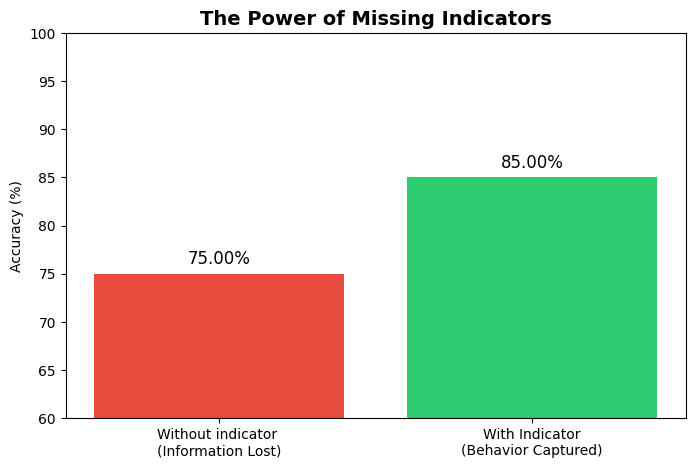

In [11]:
# Visualizing the difference
plt.figure(figsize=(8, 5))
bars = plt.bar(['Without indicator \n(Information Lost)', 'With Indicator\n(Behavior Captured)'],
               [acc_std * 100, acc_smart * 100],
               color= ['#e74c3c', '#2ecc71'])

plt.ylim(60, 100) # Zoom in to see the difference clearly
plt.ylabel('Accuracy (%)')
plt.title('The Power of Missing Indicators', fontsize=14, fontweight='bold')

# Add exact numbers on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center', fontsize=12)

plt.show()

In [12]:
print("\n--- Why did this happen? ---")
print("Model A saw a bunch of people with the 'average' salary and got confused because they weren't buying the product.")
print("Model B saw a bunch of people with the 'average' salary, but it ALSO saw a '1' in the new Missing_Indicator column. It quickly learned: 'Ah! Missing salary = Low income = Won't buy!'")


--- Why did this happen? ---
Model A saw a bunch of people with the 'average' salary and got confused because they weren't buying the product.
Model B saw a bunch of people with the 'average' salary, but it ALSO saw a '1' in the new Missing_Indicator column. It quickly learned: 'Ah! Missing salary = Low income = Won't buy!'
